# Prueba de descarga de precios + backtest de contexto
Este notebook junta tus **dos códigos** para que puedas:
1) Descargar precios con `yfinance` y guardarlos en `./data/<TICKER>/`.
2) Ejecutar el análisis de contextos (caídas vs días de salida), ver gráficas y tabla de operaciones.

⚠️ Nota: si ejecutas esto en un entorno sin internet, la descarga puede fallar.

In [6]:
from __future__ import annotations
from pathlib import Path
from IPython.display import display

# B) Sin input (recomendado para repetir pruebas)
from data_loader import download_ticker_data
from model import run_context_analysis

%matplotlib inline


AAPL: datos guardados en data/AAPL/AAPL_precios.csv
EPAM: datos guardados en data/EPAM/EPAM_precios.csv
OXY: datos guardados en data/OXY/OXY_precios.csv


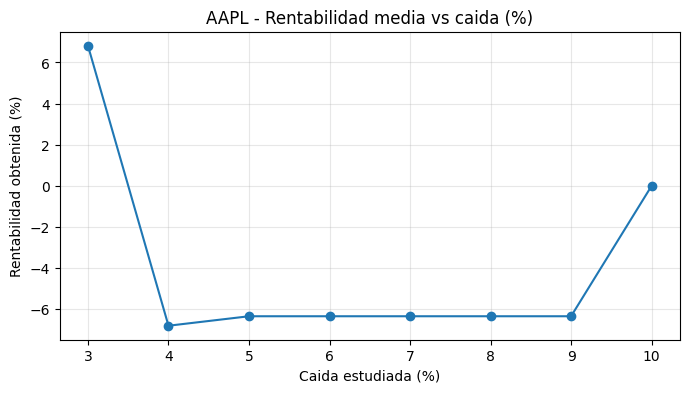

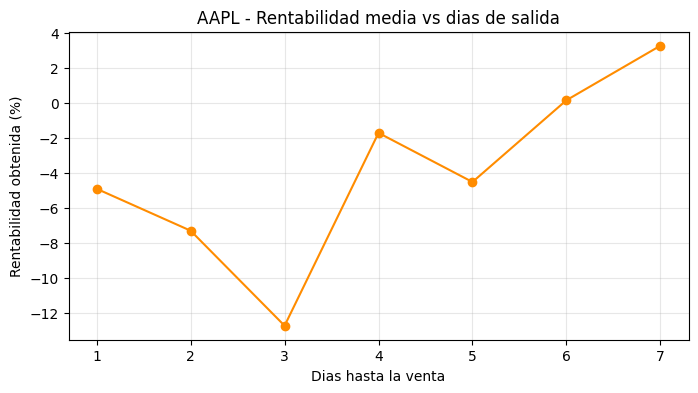

,Ticker,Caida_%,Dias_salida,Fecha_inicio,Fecha_final,Precio_compra,Precio_venta,Capital_aportado,Capital_liquidado,Rentabilidad_operacion_%
0,AAPL,3,1,2025-03-10,2025-03-11,226.4928,219.8817,10000.00,9708.11,-2.9189
1,AAPL,3,1,2025-03-13,2025-03-14,208.7701,212.5636,9708.11,9884.51,1.8171
2,AAPL,3,1,2025-04-03,2025-04-04,202.3083,187.5625,9884.51,9164.05,-7.2887
3,AAPL,3,1,2025-04-07,2025-04-08,180.6726,171.6718,9164.05,8707.52,-4.9818
4,AAPL,3,1,2025-04-10,2025-04-11,189.5937,197.2901,8707.52,9060.99,4.0594
...,...,...,...,...,...,...,...,...,...,...
119,AAPL,9,3,2025-04-03,2025-04-08,202.3083,171.6718,10000.00,8485.65,-15.1435
120,AAPL,9,4,2025-04-03,2025-04-09,202.3083,197.9871,10000.00,9786.41,-2.1359
121,AAPL,9,5,2025-04-03,2025-04-10,202.3083,189.5937,10000.00,9371.52,-6.2848
122,AAPL,9,6,2025-04-03,2025-04-11,202.3083,197.2901,10000.00,9751.95,-2.4805


Tabla guardada en data/AAPL/AAPL_operaciones_contextos.csv


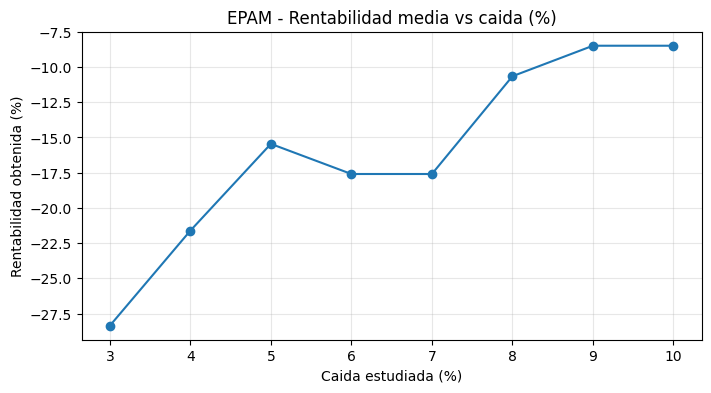

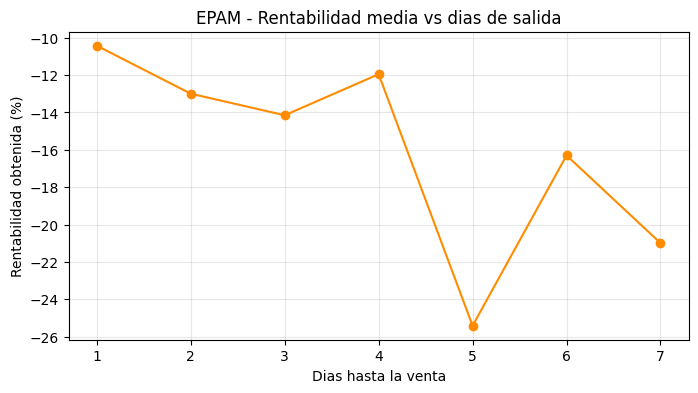

,Ticker,Caida_%,Dias_salida,Fecha_inicio,Fecha_final,Precio_compra,Precio_venta,Capital_aportado,Capital_liquidado,Rentabilidad_operacion_%
0,EPAM,3,1,2025-02-20,2025-02-21,225.07,208.84,10000.00,9278.89,-7.2111
1,EPAM,3,1,2025-03-03,2025-03-04,198.61,198.01,9278.89,9250.86,-0.3021
2,EPAM,3,1,2025-03-10,2025-03-11,190.41,191.36,9250.86,9297.01,0.4989
3,EPAM,3,1,2025-03-13,2025-03-14,180.16,182.73,9297.01,9429.64,1.4265
4,EPAM,3,1,2025-03-20,2025-03-21,172.28,175.30,9429.64,9594.93,1.7530
...,...,...,...,...,...,...,...,...,...,...
354,EPAM,10,5,2026-02-03,2026-02-10,183.33,191.61,9255.34,9673.35,4.5164
355,EPAM,10,6,2025-02-20,2025-02-28,225.07,206.14,10000.00,9158.93,-8.4107
356,EPAM,10,6,2026-02-03,2026-02-11,183.33,177.99,9158.93,8892.15,-2.9128
357,EPAM,10,7,2025-02-20,2025-03-03,225.07,198.61,10000.00,8824.37,-11.7563


Tabla guardada en data/EPAM/EPAM_operaciones_contextos.csv


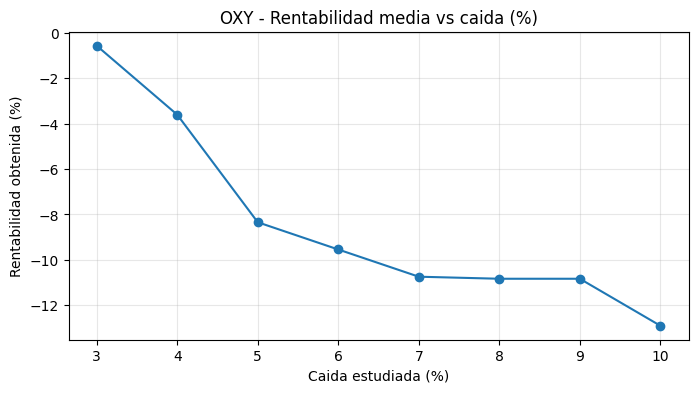

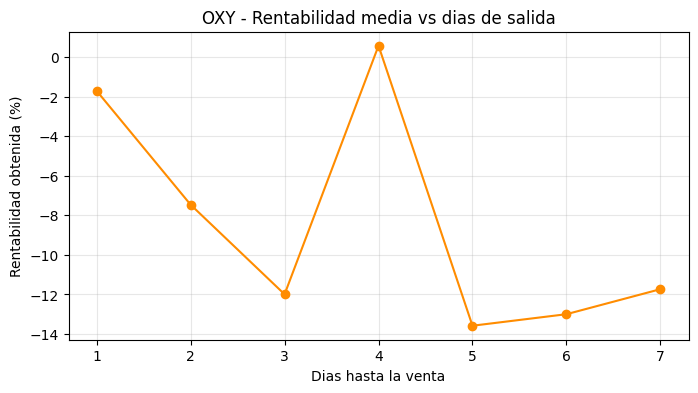

,Ticker,Caida_%,Dias_salida,Fecha_inicio,Fecha_final,Precio_compra,Precio_venta,Capital_aportado,Capital_liquidado,Rentabilidad_operacion_%
0,OXY,3,1,2025-02-21,2025-02-24,49.3336,48.7856,10000.00,9888.93,-1.1107
1,OXY,3,1,2025-03-03,2025-03-04,45.4491,45.5274,9888.93,9905.96,0.1722
2,OXY,3,1,2025-04-03,2025-04-04,43.1734,39.8690,9905.96,9147.78,-7.6538
3,OXY,3,1,2025-04-07,2025-04-08,38.1086,35.5123,9147.78,8524.55,-6.8129
4,OXY,3,1,2025-04-10,2025-04-11,35.8664,37.0465,8524.55,8805.04,3.2904
...,...,...,...,...,...,...,...,...,...,...
228,OXY,10,3,2025-04-03,2025-04-08,43.1734,35.5123,10000.00,8225.51,-17.7449
229,OXY,10,4,2025-04-03,2025-04-09,43.1734,39.5641,10000.00,9164.01,-8.3599
230,OXY,10,5,2025-04-03,2025-04-10,43.1734,35.8664,10000.00,8307.52,-16.9248
231,OXY,10,6,2025-04-03,2025-04-11,43.1734,37.0465,10000.00,8580.87,-14.1913


Tabla guardada en data/OXY/OXY_operaciones_contextos.csv


In [7]:

tickers = ['AAPL', 'EPAM', 'OXY']  # cambia aquí
precios = download_ticker_data(tickers, days=365)

# Parametría (ajusta a tu gusto)
capital_inicial = 10000.0
caidas = list(range(3, 11))       # 3%..10%
dias_salida = list(range(1, 8))   # 1..7 días

run_context_analysis(
    precios,
    capital_inicial=capital_inicial,
    caidas=caidas,
    dias_salida=dias_salida,
    base_dir='data'
)
